### Approach comparison

Holding the Trillion Dollar Words benchmark fixed, how do the four ways of using a
language model compare? Rule-based, frozen probe, fine-tuned encoder, zero-shot LLM.

Reads `../results.csv` and renders the ranked table, shaded by approach.

In [1]:
import matplotlib.pyplot as plt
import polars as pl
from matplotlib.patches import Rectangle

# match the thesis body font (Computer Modern), as in the architecture diagrams
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["cmr10", "DejaVu Serif"],
        "font.monospace": ["cmtt10", "DejaVu Sans Mono"],
        "mathtext.fontset": "cm",
        "axes.unicode_minus": False,
    }
)

In [2]:
import sys

sys.path.insert(0, "..")
from config import RESULTS_DIR

# mean and std across seeds, ranked by macro-F1.
# lora-/head-only/dapt rows belong to their own ablation figures, not this
# table; deberta is out of the thesis (6 encoders).
d = (
    pl.read_csv(RESULTS_DIR / "results.csv")
    .filter(pl.col("corpus") == "twd")
    .filter(~pl.col("model").str.starts_with("lora-"))
    .filter(~pl.col("model").str.starts_with("head-only:"))
    .filter(~pl.col("model").str.starts_with("dapt-"))
    .filter(~pl.col("model").str.starts_with("frozen-dapt-"))
    .filter(~pl.col("model").str.contains("deberta"))
    .group_by("model")
    .agg(
        pl.col("macro_f1").mean().alias("m"),
        pl.col("macro_f1").std(ddof=0).alias("ms"),
        pl.col("weighted_f1").mean().alias("w"),
        pl.col("weighted_f1").std(ddof=0).alias("ws"),
        pl.len().alias("n"),
    )
    .sort("m", descending=True)
)
print(d)

shape: (21, 6)
┌───────────────────────────┬──────────┬──────────┬──────────┬──────────┬─────┐
│ model                     ┆ m        ┆ ms       ┆ w        ┆ ws       ┆ n   │
│ ---                       ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ --- │
│ str                       ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ u32 │
╞═══════════════════════════╪══════════╪══════════╪══════════╪══════════╪═════╡
│ roberta-large             ┆ 0.7069   ┆ 0.017555 ┆ 0.717567 ┆ 0.01411  ┆ 3   │
│ zero-shot:claude-fable-5  ┆ 0.676467 ┆ 0.009827 ┆ 0.684233 ┆ 0.01095  ┆ 3   │
│ zero-shot:claude-opus-4-8 ┆ 0.665333 ┆ 0.00633  ┆ 0.677067 ┆ 0.007956 ┆ 3   │
│ zero-shot:claude-sonnet-5 ┆ 0.6629   ┆ 0.014102 ┆ 0.677133 ┆ 0.008146 ┆ 3   │
│ roberta-base              ┆ 0.657533 ┆ 0.011376 ┆ 0.676033 ┆ 0.013757 ┆ 3   │
│ …                         ┆ …        ┆ …        ┆ …        ┆ …        ┆ …   │
│ bow                       ┆ 0.559167 ┆ 0.019969 ┆ 0.582067 ┆ 0.016443 ┆ 3   │
│ word2vec               

In [3]:
# one colour per model type
COLORS = {
    "fine-tuned": "#cfe3f7",
    "zero-shot LLM": "#cfeddb",
    "frozen": "#fbe6c2",
    "traditional NLP": "#e6d9f2",
    "chance": "#f5d5d5",
}

PRETTY = {
    "roberta-large": "RoBERTa-large",
    "roberta-base": "RoBERTa-base",
    "bert-large-uncased": "BERT-large",
    "bert-base-uncased": "BERT-base",
    "flang-bert": "FLANG-BERT",
    "flang-roberta": "FLANG-RoBERTa",
    "claude-fable-5": "Fable 5",
    "claude-opus-4-8": "Opus 4.8",
    "claude-sonnet-5": "Sonnet 5",
    "claude-haiku-4-5": "Haiku 4.5",
    "bow": "bag-of-words",
    "word2vec": "word2vec",
    "random": "random guess",
    "always-neutral": "always neutral",
    "rule-based": "rule-based",
}


def kind(m):
    if m.startswith("frozen:"):
        return "frozen"
    if m.startswith("zero-shot:"):
        return "zero-shot LLM"
    if m in ("bow", "word2vec", "rule-based"):
        return "traditional NLP"
    if m in ("random", "always-neutral"):
        return "chance"
    return "fine-tuned"


def label(m):
    name = PRETTY.get(m.split(":", 1)[-1], m.split(":", 1)[-1])
    if m.startswith("frozen:"):
        return f"frozen {name}"
    if m.startswith("zero-shot:"):
        return f"LLM {name}"
    if kind(m) == "fine-tuned":
        return f"finetuned {name}"
    return name


# trainable parameters per system. frozen rows train only the logistic head
# (d x 3 + 3); bow trains one weight per vocabulary item; LLM counts are not
# published.
PARAMS = {
    "roberta-large": "355M",
    "bert-large-uncased": "335M",
    "roberta-base": "125M",
    "flang-roberta": "135M",
    "bert-base-uncased": "110M",
    "flang-bert": "110M",
    "bow": "7,056",
    "word2vec": "903",
    "rule-based": "0",
    "random": "0",
    "always-neutral": "0",
}


def params(m):
    if m.startswith("zero-shot:"):
        return "n/a"
    if m.startswith("frozen:"):
        return "3,075" if "large" in m else "2,307"
    return PARAMS.get(m, "")

C:\Users\vpati\AppData\Local\Temp\ipykernel_37084\2160022912.py:4: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(figsize=(8.6, (n + 1.55) * 0.38))


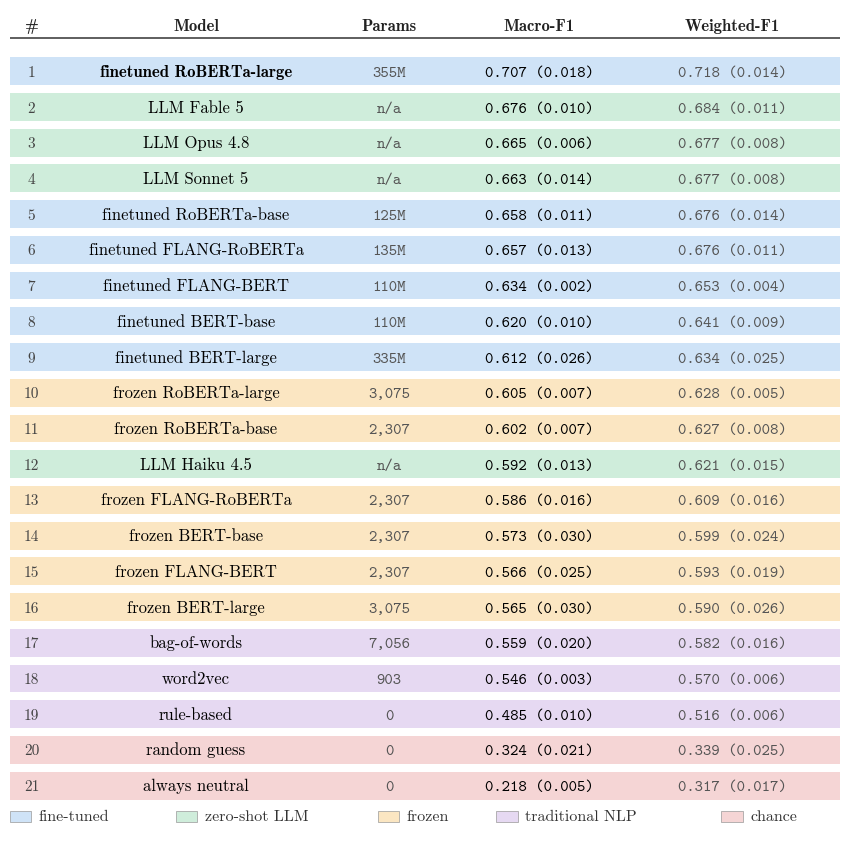

In [4]:
rows = d.to_dicts()
n = len(rows)

fig, ax = plt.subplots(figsize=(8.6, (n + 1.55) * 0.38))
ax.set_xlim(0, 11.6)
# room below zero for the legend, else the patches get clipped away
ax.set_ylim(-1.1, n + 1.05)
ax.axis("off")

# header
hy = n + 0.45
for x, t, ha in [
    (0.30, "#", "center"),
    (2.60, "Model", "center"),
    (5.30, "Params", "center"),
    (7.40, "Macro-F1", "center"),
    (10.10, "Weighted-F1", "center"),
]:
    ax.text(x, hy, t, fontsize=12, fontname="cmb10", ha=ha, color="#222")
ax.plot([0, 11.6], [hy - 0.22, hy - 0.22], color="#333", lw=1.1)

# one shaded band per model
for i, r in enumerate(rows):
    y = n - 1 - i
    fam = "cmb10" if i == 0 else "cmr10"
    ax.add_patch(
        Rectangle(
            (0, y - 0.08),
            11.6,
            0.78,
            facecolor=COLORS[kind(r["model"])],
            edgecolor="none",
        )
    )
    ax.text(0.30, y + 0.18, str(i + 1), fontsize=11, ha="center", color="#444")
    ax.text(2.6, y + 0.18, label(r["model"]), fontsize=12, fontname=fam, ha="center")
    ax.text(
        5.30,
        y + 0.18,
        params(r["model"]),
        fontsize=11.5,
        ha="center",
        family="monospace",
        color="#555",
    )
    ax.text(
        7.40,
        y + 0.18,
        f"{r['m']:.3f} ({r['ms']:.3f})",
        fontsize=11.5,
        ha="center",
        family="monospace",
    )
    ax.text(
        10.10,
        y + 0.18,
        f"{r['w']:.3f} ({r['ws']:.3f})",
        fontsize=11.5,
        ha="center",
        family="monospace",
        color="#555",
    )

# legend
# slots proportional to label length, so a long name can't crowd its neighbour
widths = [len(k) + 4 for k in COLORS]
scale = 11.6 / sum(widths)
x = 0.0
for (k, c), w in zip(COLORS.items(), widths):
    ax.add_patch(
        Rectangle((x, -0.72), 0.30, 0.32, facecolor=c, edgecolor="#999", lw=0.5)
    )
    ax.text(x + 0.40, -0.56, k, fontsize=11.5, color="#333", va="center")
    x += w * scale

fig.tight_layout()
fig.savefig("approach_comparison.png", dpi=200, bbox_inches="tight", facecolor="white")
fig.savefig("approach_comparison.pdf", bbox_inches="tight", facecolor="white")

### Data

- 2,480 FOMC sentences labelled hawkish, dovish, or neutral
- Meeting minutes 46%, speeches 41%, press conferences 13%
- 1996-2022; 80/20 train/test, 3 seeds when doing the train-test split
- We look at weighted F1 and macro F1

### Method

*Finetuning Encoders: Training Methodology*
- Sentence -> ~35 tokens -> each becomes a 768-dim vector
- We then rebuild each of those vectors over 12 layers in context (output then is also [n x 768])
- Each word genuinely gets different vectors depending on its neighbors.
- We bolt on a final layer (768 ->3 ) which maps our [CLS] vector to a 3 dimensional vector
- Cross entropy loss backpropogates from those 3 logits down all 12 layers, updating every one of the 110m parameters, whole network reshapes to make stance separable.

*Finetuning Encoders: Hyperparameter Selection*
- Hyperparameters learning rates/batch sizes grid-searched and winner selected based on best 
- Early stopping on validation loss, accuracy and F1
- Final model is scored, not the best checkpoint
- Note: ModernBert an FLANG models didn't get their own gridd search, they borrowed. On my to-do list to grid search these models.

*Other Models*
- Rule-based: keyword dictionary with negation, nothing learned
- Frozen probe: Instead of fine-tuning, we take the frozen 768-dim in-context vectors for every token, mean-pool them into one sentence vector, and fit logistic regression on that.
- LLMs: zero-shot, Shah's prompt, no training examples

### Conclusion
- Traditional NLP is weakest: dictionary, counts and static embeddings all land below 0.56
    - Anything that discards word order / context caps near 0.55, regardless of vector quality
    - word2vec (0.4899) barely beats the keyword dictionary (0.4851) — mean-pooling isn't ideal (word2vec vectors representing tightening & loosening are quite similar actually, so a phrase "policy tightening" is quite similar to "policy loosening" with these static embeddings) 

- Fine-tuned RoBERTa-large still beats frontier zero-shot LLMs
    - A 355M open-weight model, run locally on free hardware, beats a closed API costing ~$3 per pass
    - Matters where text cannot leave the building: reproducible, auditable, no vendor or version dependency
- Fine-tuning beats frozen features for every encoder
- Fine-tuning, not representation quality, separates the encoders
- Finance-specific pretraining doesn't pay: FinBERT 10th, both FLANGS below plain BERT-large
    - Those models learning filings and earnings calls - finance, but a different register from central banking
    - DAPT: perhaps continueing pretrainong on the 12.5M words we collected of unlabelled FOMC text, might be a great way for the model to learn tone, syntax, jargon of central bank specific language.


### Plan

- Then: See if adding statements (Patil UDA project, VoMP papers)to the training data improves performance?
    - Does labaelled statement data improve performance? Cross-register transfer. No one has studied this to my knowledge.
    - Limitation - annotators are different. Not sure how to address this?
- Then: Does 23,000 sentences from 24 other central banks help predict the Fed? Cross-institution transfer. 
- Then: Re-run on chronological split, train 1996-2019, test 200-22 - boilerplate leaks across. 
    - In the Shah paper, there were 10-15 sentences that were verbatim in both train and test
    - Does this work in a non-cheating way? Chronological splits understudied in literature?
- DAPT: continue pretraining RoBERTa on 12.5m words of Fed text we compiled
    - 12.5M words of unlabelled FOMC text abd 20m words across 25 central banks — meeting transcripts, minutes, speeches — with every labelled sentence stripped out first to prevent leakage
- Figuring out how all these experiments fit together